<a href="https://colab.research.google.com/github/Fatema5007/Deep-Learning-Foundations/blob/main/CNN_vs_ANN_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Base transformations for both models (just normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Download and Load CIFAR-10
print("Downloading and loading CIFAR-10 dataset...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print("Data setup complete!")

100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s]


Data setup complete!


In [3]:
def train_and_evaluate(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_acc = 100.0 * correct / total
        train_accuracies.append(epoch_acc)
        print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {running_loss/len(train_loader):.4f} | Train Acc: {epoch_acc:.2f}%")

    total_time = time.time() - start_time
    print(f"\nTraining Finished in {total_time:.2f} seconds.")

    # Evaluate on Test Set
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100.0 * test_correct / test_total
    print(f"Final Test Accuracy: {test_acc:.2f}%")

    return train_accuracies, test_acc, total_time

In [4]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self):
        super(MultiLayerPerceptron, self).__init__()
        # Input size: 3 channels * 32 * 32 pixels = 3072
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10) # 10 Output classes

    def forward(self, x):
        # Flatten the input image from (batch_size, 3, 32, 32) to (batch_size, 3072)
        x = x.view(-1, 3 * 32 * 32)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Instantiate and train ANN
print("--- Training ANN Model ---")
ann_model = MultiLayerPerceptron().to(device)
ann_train_acc, ann_test_acc, ann_time = train_and_evaluate(ann_model, trainloader, testloader, epochs=10)

--- Training ANN Model ---
Epoch [1/10] -> Loss: 1.6706 | Train Acc: 40.34%
Epoch [2/10] -> Loss: 1.4612 | Train Acc: 48.33%
Epoch [3/10] -> Loss: 1.3601 | Train Acc: 51.93%
Epoch [4/10] -> Loss: 1.2756 | Train Acc: 54.64%
Epoch [5/10] -> Loss: 1.2050 | Train Acc: 57.24%
Epoch [6/10] -> Loss: 1.1455 | Train Acc: 59.34%
Epoch [7/10] -> Loss: 1.0768 | Train Acc: 61.67%
Epoch [8/10] -> Loss: 1.0186 | Train Acc: 63.88%
Epoch [9/10] -> Loss: 0.9640 | Train Acc: 65.56%
Epoch [10/10] -> Loss: 0.9133 | Train Acc: 67.27%

Training Finished in 273.99 seconds.
Final Test Accuracy: 53.65%


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # After three MaxPool operations on 32x32, spatial size becomes 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 8x8
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))  # 4x4

        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and train CNN
print("--- Training CNN Model ---")
cnn_model = SimpleCNN().to(device)
cnn_train_acc, cnn_test_acc, cnn_time = train_and_evaluate(cnn_model, trainloader, testloader, epochs=10)

--- Training CNN Model ---
Epoch [1/10] -> Loss: 1.3631 | Train Acc: 50.34%
Epoch [2/10] -> Loss: 0.9043 | Train Acc: 68.23%
Epoch [3/10] -> Loss: 0.7009 | Train Acc: 75.31%
Epoch [4/10] -> Loss: 0.5652 | Train Acc: 80.04%
Epoch [5/10] -> Loss: 0.4511 | Train Acc: 84.21%
Epoch [6/10] -> Loss: 0.3560 | Train Acc: 87.45%
Epoch [7/10] -> Loss: 0.2724 | Train Acc: 90.39%
Epoch [8/10] -> Loss: 0.2124 | Train Acc: 92.59%
Epoch [9/10] -> Loss: 0.1765 | Train Acc: 93.73%
Epoch [10/10] -> Loss: 0.1439 | Train Acc: 94.97%

Training Finished in 1795.93 seconds.
Final Test Accuracy: 75.82%


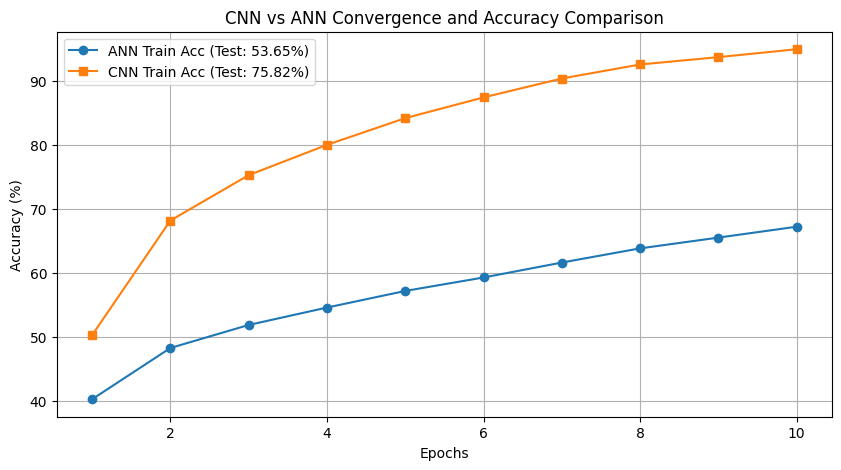


             SUMMARY TABLE             
Model      | Test Accuracy   | Training Time  
----------------------------------------
ANN        | 53.65%       | 273.99s
CNN        | 75.82%       | 1795.93s


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), ann_train_acc, label=f'ANN Train Acc (Test: {ann_test_acc:.2f}%)', marker='o')
plt.plot(range(1, 11), cnn_train_acc, label=f'CNN Train Acc (Test: {cnn_test_acc:.2f}%)', marker='s')

plt.title('CNN vs ANN Convergence and Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*40)
print("             SUMMARY TABLE             ")
print("="*40)
print(f"{'Model':<10} | {'Test Accuracy':<15} | {'Training Time':<15}")
print("-"*40)
print(f"{'ANN':<10} | {ann_test_acc:.2f}%{' ':<6} | {ann_time:.2f}s")
print(f"{'CNN':<10} | {cnn_test_acc:.2f}%{' ':<6} | {cnn_time:.2f}s")
print("="*40)